In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt
from sklearn.decomposition import NMF, PCA, DictionaryLearning

import config
from data import load_utk
from utils import apply_symmetric_noise

In [2]:
array = load_utk()[:5000]
# noise_prob = 0.25
# noisy_array = apply_symmetric_noise(array, prob=noise_prob)
binarized_array = (array / array.max(axis=1, keepdims=True) > 0.5).astype(array.dtype)

In [3]:
def get_sorted_indices(vector, dataset_arr):
    vector_flat = vector.flatten()
    dataset_flat = dataset_arr.reshape(dataset_arr.shape[0], -1)
    
    dot_products = np.dot(dataset_flat, vector_flat)
    
    norm_vector = np.linalg.norm(vector_flat)
    norms_dataset = np.linalg.norm(dataset_flat, axis=1)
    
    epsilon = 1e-10
    norms_dataset = np.where(norms_dataset == 0, epsilon, norms_dataset)
    norm_vector = norm_vector if norm_vector != 0 else epsilon
    
    cosine_similarities = dot_products / (norm_vector * norms_dataset)
    
    return np.argsort(-cosine_similarities)

In [4]:
data = list()
for k_hidden in tqdm(list(range(18, 108, 18))):
    # NNMF
    model = NMF(n_components=k_hidden, max_iter=200000, init="random", random_state=config.SEED)
    W_sklearn = model.fit_transform(binarized_array)
    H_sklearn = model.components_
    nnmf_recovered_images_array = np.dot(W_sklearn, H_sklearn)
    
    nnmf_success_num = 0
    nnmf_arr_num = 0
    for idx in range(nnmf_recovered_images_array.shape[0]):
        sorted_indices = get_sorted_indices(nnmf_recovered_images_array[idx], array)
        if sorted_indices[0] == idx:
            nnmf_success_num += 1
        nnmf_arr_num += 1 / ( np.where(sorted_indices == idx)[0].item() + 1 )
    
    nnmf_accuracy = nnmf_success_num / binarized_array.shape[0]
    nnmf_arr = nnmf_arr_num / binarized_array.shape[0]
    
    # PCA
    pca = PCA(n_components=k_hidden, random_state=config.SEED)
    X_transformed = pca.fit_transform(binarized_array)
    pca_recovered_images_array = pca.inverse_transform(X_transformed)
    
    pca_success_num = 0
    pca_arr_num = 0
    for idx in range(pca_recovered_images_array.shape[0]):
        sorted_indices = get_sorted_indices(pca_recovered_images_array[idx], array)
        if sorted_indices[0] == idx:
            pca_success_num += 1
        pca_arr_num += 1 / ( np.where(sorted_indices == idx)[0].item() + 1 )
    
    pca_accuracy = pca_success_num / binarized_array.shape[0]
    pca_arr = pca_arr_num / binarized_array.shape[0]

    # Dictionary
    # n_nonzero_coefs = max(1, int(k_hidden / 2))
    n_nonzero_coefs = k_hidden
    dict_learner = DictionaryLearning(
        # alpha=0.01,
        n_components=k_hidden, 
        transform_algorithm="omp", 
        transform_n_nonzero_coefs=n_nonzero_coefs,
        random_state=config.SEED
    )
    X_codes = dict_learner.fit_transform(binarized_array)
    dict_recovered_images_array = X_codes.dot(dict_learner.components_)

    dict_success_num = 0
    dict_arr_num = 0
    for idx in range(dict_recovered_images_array.shape[0]):
        sorted_indices = get_sorted_indices(dict_recovered_images_array[idx], array)
        if sorted_indices[0] == idx:
            dict_success_num += 1
        dict_arr_num += 1 / ( np.where(sorted_indices == idx)[0].item() + 1 )
    
    dict_accuracy = dict_success_num / binarized_array.shape[0]
    dict_arr = dict_arr_num / binarized_array.shape[0]

    
    data.append(
        [
            k_hidden,
            nnmf_accuracy,
            pca_accuracy,
            dict_accuracy,
            nnmf_arr,
            pca_arr,
            dict_arr
        ]
    )


00%|█████████████████████████████████████████| 5/5 [4:54:26<00:00, 3533.37s/it]

In [5]:
df_data = pd.DataFrame(
    data,
    columns=[
        "k_hidden",
        "nnmf_accuracy",
        "pca_accuracy",
        "dict_accuracy",
        "nnmf_arr",
        "pca_arr",
        "dict_arr"
    ]
)
df_data

,k_hidden,nnmf_accuracy,pca_accuracy,dict_accuracy,nnmf_arr,pca_arr,dict_arr
0,18,0.3358,0.4408,0.2388,0.456302,0.554699,0.352700
1,36,0.6664,0.7170,0.4506,0.747913,0.789116,0.564317
2,54,0.7730,0.8042,0.5508,0.831909,0.857817,0.653275
3,72,0.8188,0.8424,0.6228,0.869612,0.887866,0.710804
4,90,0.8488,0.8646,0.6620,0.891867,0.904430,0.744002


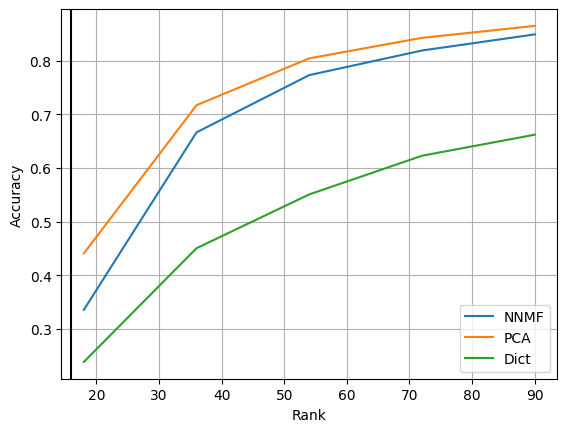

In [8]:
plt.plot(df_data.k_hidden, df_data.nnmf_accuracy, label="NNMF")
plt.plot(df_data.k_hidden, df_data.pca_accuracy, label="PCA")
plt.plot(df_data.k_hidden, df_data.dict_accuracy, label="Dict")
plt.axvline(16, color="black")

plt.xlabel("Rank")
plt.ylabel("Accuracy")

plt.grid()

plt.legend()

# plt.savefig(f"images/UTK_denoising_comparison_accuracy_{int(noise_prob * 100)}.pdf")
plt.savefig(f"images/UTK_denoising_comparison_accuracy_binarized.pdf")

plt.show()

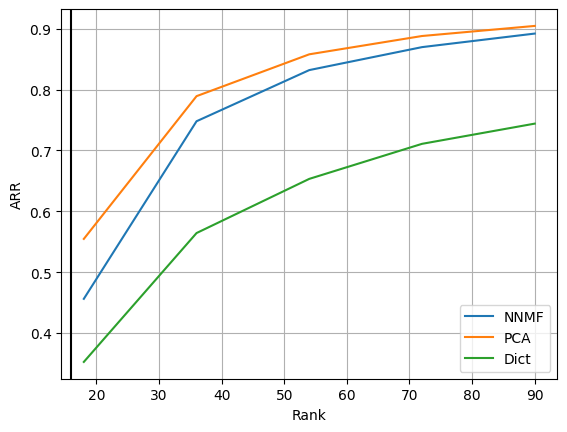

In [10]:
plt.plot(df_data.k_hidden, df_data.nnmf_arr, label="NNMF")
plt.plot(df_data.k_hidden, df_data.pca_arr, label="PCA")
plt.plot(df_data.k_hidden, df_data.dict_arr, label="Dict")
plt.axvline(16, color="black")

plt.xlabel("Rank")
plt.ylabel("ARR")

plt.grid()

plt.legend()

plt.savefig(f"images/UTK_denoising_comparison_ARR_binarized.pdf")

plt.show()